In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
import os 

In [3]:
from pathlib import Path
data = Path.cwd().parent / "Data" / "creditcard" / "creditcard.csv"
df = pd.read_csv(data)

In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.shape

(284807, 31)

In [7]:
print(df.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [8]:
counts = df["Class"].value_counts().sort_index()
ratio = df["Class"].value_counts(normalize=True).sort_index()

print("Counts:\n", counts)
print("\nRatios:\n", ratio.round(4))

Counts:
 Class
0    284315
1       492
Name: count, dtype: int64

Ratios:
 Class
0    0.9983
1    0.0017
Name: proportion, dtype: float64


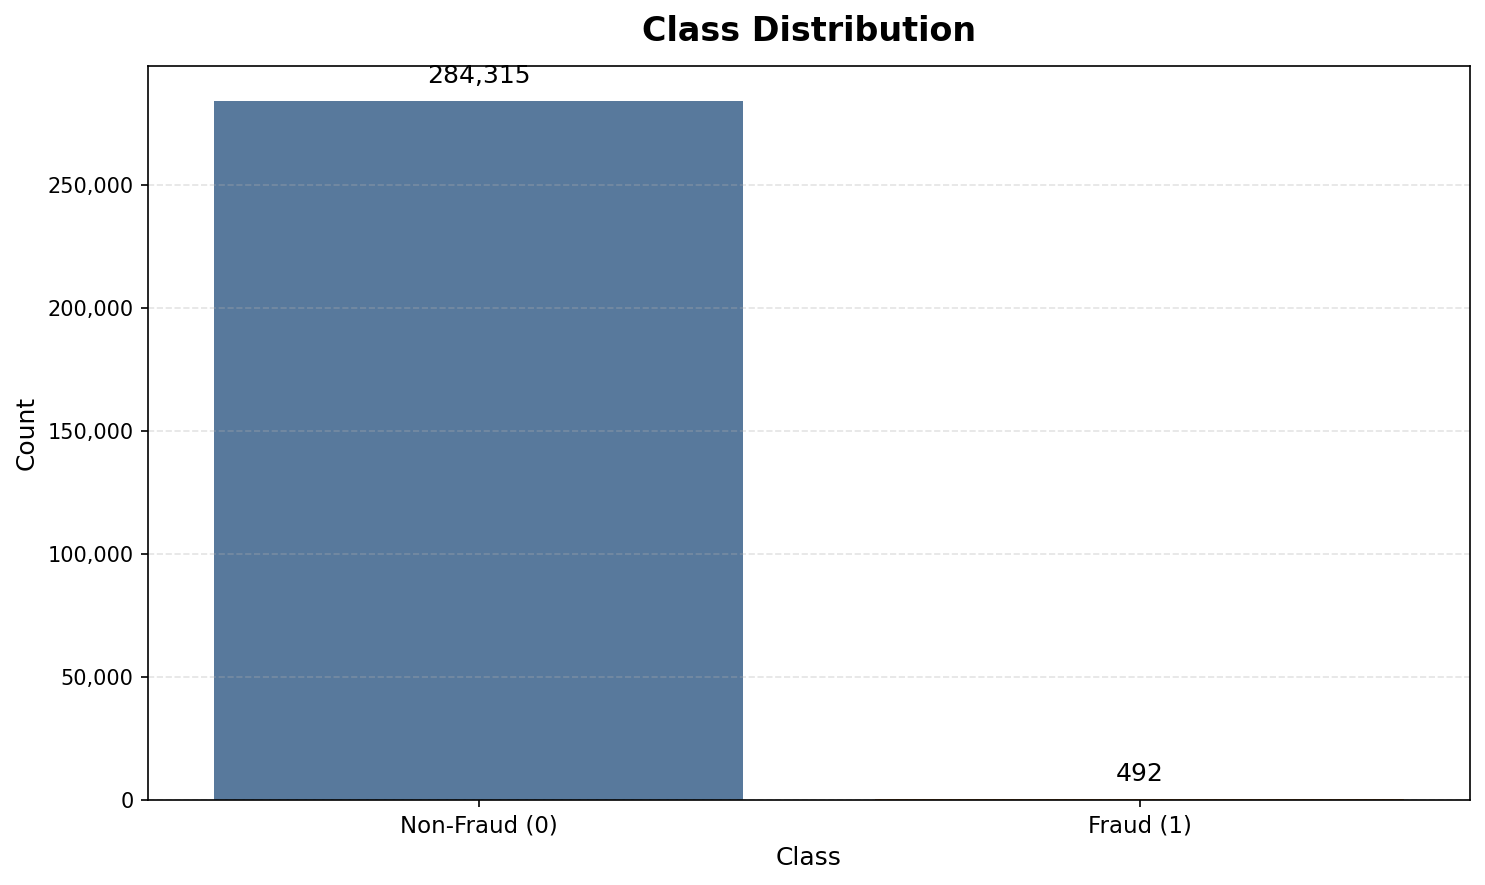

Saved chart to: c:\Users\aamir\Accuracy-Paradox\assets\screenshots\class_distribution_ppt.png


In [5]:
from pathlib import Path
import matplotlib.ticker as mtick

plt.figure(figsize=(10, 6), dpi=150)
ax = sns.countplot(
    x="Class",
    hue="Class",
    data=df,
    palette={0: "#4C78A8", 1: "#F58518"},
    legend=False,
    order=[0, 1],
)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=12,
        color="black",
        xytext=(0, 6),
        textcoords="offset points",
    )

ax.set_title("Class Distribution", fontsize=16, weight="bold", pad=12)
ax.set_xlabel("Class", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Non-Fraud (0)", "Fraud (1)"], fontsize=11)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()

out_dir = Path.cwd().parent / "assets" / "screenshots"
out_dir.mkdir(parents=True, exist_ok=True)
out_file = out_dir / "class_distribution_ppt.png"
plt.savefig(out_file, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved chart to: {out_file}")

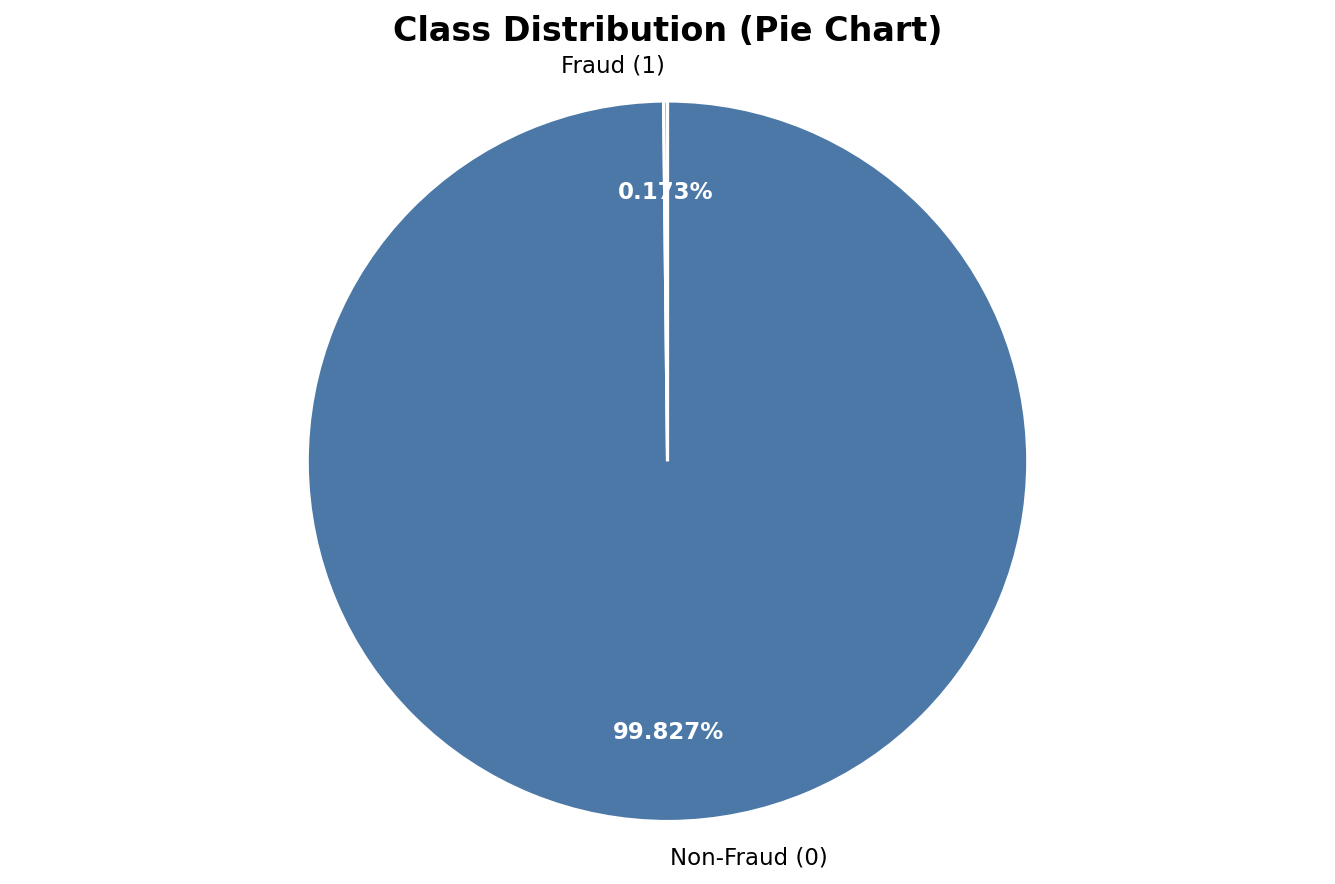

Saved chart to: c:\Users\aamir\Accuracy-Paradox\assets\screenshots\class_distribution_pie_ppt.png


In [6]:
from pathlib import Path

counts = df["Class"].value_counts().sort_index()
labels = ["Non-Fraud (0)", "Fraud (1)"]
colors = ["#4C78A8", "#F58518"]

plt.figure(figsize=(9, 6), dpi=150)
wedges, texts, autotexts = plt.pie(
    counts.values,
    labels=labels,
    colors=colors,
    autopct="%1.3f%%",
    startangle=90,
    counterclock=False,
    pctdistance=0.75,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)

plt.title("Class Distribution (Pie Chart)", fontsize=16, weight="bold", pad=12)
plt.axis("equal")

for t in texts:
    t.set_fontsize(11)
for at in autotexts:
    at.set_color("white")
    at.set_fontsize(11)
    at.set_weight("bold")

out_dir = Path.cwd().parent / "assets" / "screenshots"
out_dir.mkdir(parents=True, exist_ok=True)
out_file = out_dir / "class_distribution_pie_ppt.png"
plt.tight_layout()
plt.savefig(out_file, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved chart to: {out_file}")

## The class distribution is extremely skewed (Class 0 = 284,315, Class 1 = 492), confirming a highly imbalanced dataset.
## A naive model can achieve very high accuracy by predicting the majority class only, while failing to detect fraud.
## Therefore, accuracy alone is not a reliable metric for this problem.
## Evaluation should focus on minority-sensitive metrics such as Recall, F1-score, PR-AUC, and confusion matrix.
## To build a useful fraud detector, imbalance-handling methods (class weights, SMOTE, threshold tuning) are necessary.

In [10]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## V1 to V28 are features created using PCA (Principal Component Analysis) from the original confidential transaction variables.
## Original column names were removed to protect cardholder/bank information.
## So you can’t interpret V3 or V17 semantically (“this means country/device”), but they still carry predictive signal.

In [11]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [13]:

#1 Feature Target
X = df.drop("Class", axis=1)
y = df["Class"]

#2 Stratified Split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
#3 Standardize Features
scale_cols = ['Time', 'Amount']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc, accuracy_score, recall_score, precision_score, f1_score, average_precision_score

In [24]:
#4 Train Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [25]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [26]:
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Recall  :", round(recall_score(y_test, y_pred), 4))
print("F1      :", round(f1_score(y_test, y_pred), 4))
print("PR-AUC  :", round(average_precision_score(y_test, y_prob), 4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9755
Recall  : 0.9184
F1      : 0.1144
PR-AUC  : 0.7159
Confusion Matrix:
 [[55478  1386]
 [    8    90]]


In [1]:
word = 'Word'
word[0:4]

'Word'